In [1]:
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import numpy as np

%matplotlib inline



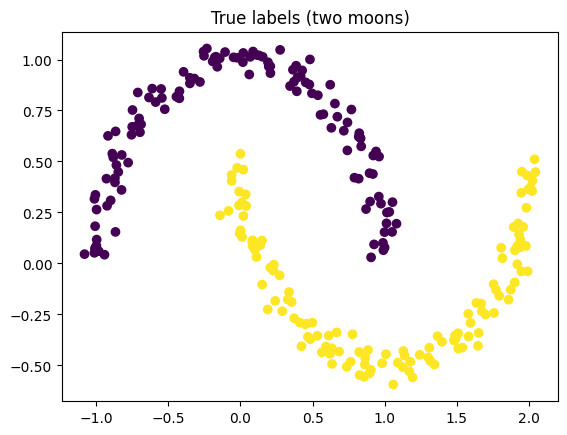

In [2]:
# Non‑linear dataset
X, y = make_moons(n_samples=250, noise=0.05, random_state=42)

plt.scatter(X[:,0], X[:,1], c=y, cmap="viridis")
plt.title("True labels (two moons)")
plt.show()


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [4]:
dbscan = DBSCAN(eps=0.3, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

print("Cluster labels:", np.unique(labels))
print("Noise points:", np.sum(labels == -1))


Cluster labels: [0 1]
Noise points: 0


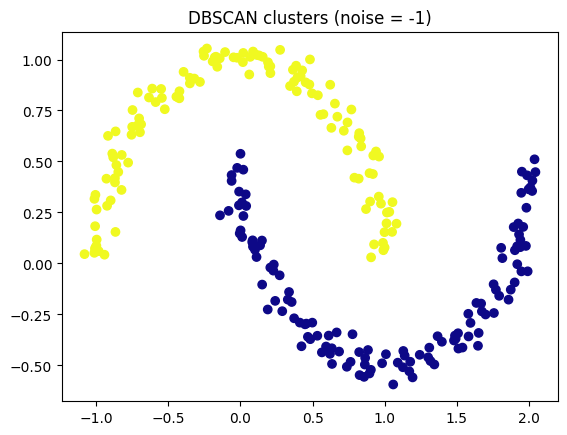

In [5]:
plt.scatter(X[:,0], X[:,1], c=labels, cmap="plasma")
plt.title("DBSCAN clusters (noise = -1)")
plt.show()


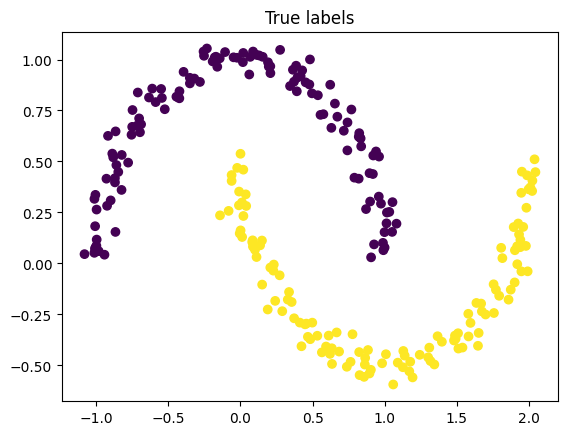

In [6]:
plt.scatter(X[:,0], X[:,1], c=y, cmap="viridis")
plt.title("True labels")
plt.show()


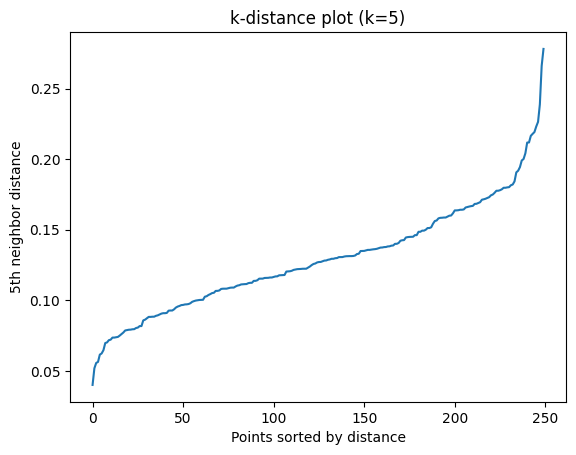

In [7]:
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, _ = neighbors_fit.kneighbors(X_scaled)

# sort distances of the 5th neighbor
distances = np.sort(distances[:, 4])

plt.plot(distances)
plt.title("k-distance plot (k=5)")
plt.xlabel("Points sorted by distance")
plt.ylabel("5th neighbor distance")
plt.show()


In [8]:
from kneed import KneeLocator
from sklearn.neighbors import NearestNeighbors
import numpy as np

k = 5
neighbors = NearestNeighbors(n_neighbors=k).fit(X_scaled)
distances, _ = neighbors.kneighbors(X_scaled)
distances = np.sort(distances[:, k-1])

kl = KneeLocator(range(len(distances)), distances, curve="convex", direction="increasing")
print("Suggested eps:", distances[kl.elbow])


Suggested eps: 0.18017273274957507


In [9]:
from sklearn.cluster import DBSCAN
import numpy as np

eps_val = 0.18017273274957507
dbscan = DBSCAN(eps=eps_val, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

print("Clusters:", len(set(labels)) - (1 if -1 in labels else 0))
print("Noise points:", np.sum(labels == -1))


Clusters: 10
Noise points: 0


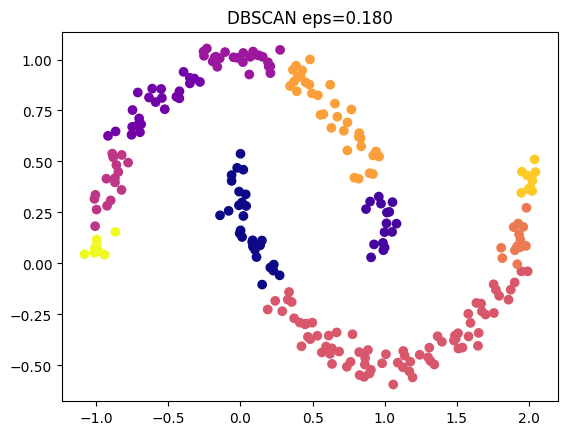

In [10]:
plt.scatter(X[:,0], X[:,1], c=labels, cmap="plasma")
plt.title(f"DBSCAN eps={eps_val:.3f}")
plt.show()


In [14]:
for eps in [0.15, 0.18, 0.22, 0.26, 0.30, 0.34]:
    labels = DBSCAN(eps=eps, min_samples=5).fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)
    print(f"eps={eps:.2f} -> clusters={n_clusters}, noise={n_noise}")


eps=0.15 -> clusters=14, noise=17
eps=0.18 -> clusters=10, noise=0
eps=0.22 -> clusters=3, noise=0
eps=0.26 -> clusters=2, noise=0
eps=0.30 -> clusters=2, noise=0
eps=0.34 -> clusters=2, noise=0


# HDBSCAN

In [11]:
import hdbscan

hdb = hdbscan.HDBSCAN(min_cluster_size=5, min_samples=5)
hdb_labels = hdb.fit_predict(X_scaled)

print("HDBSCAN clusters:", len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0))
print("HDBSCAN noise points:", np.sum(hdb_labels == -1))


HDBSCAN clusters: 2
HDBSCAN noise points: 0


/Users/himanshu/github_himanshu/mlops-playbook/ml_algorithms/.venv/lib/python3.13/site-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning: invalid escape sequence '\{'
  $max \{ core_k(a), core_k(b), 1/\alpha d(a,b) \}$.


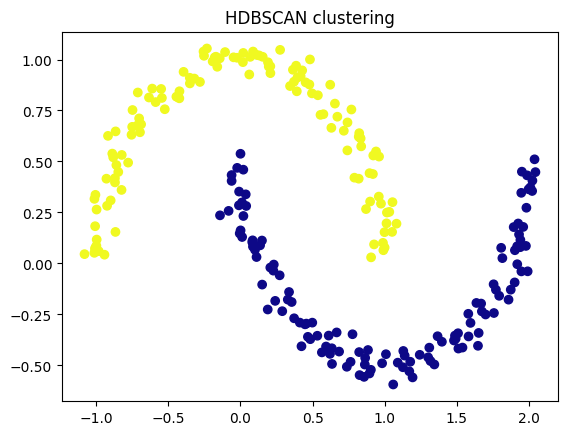

In [12]:
import matplotlib.pyplot as plt

plt.scatter(X[:,0], X[:,1], c=hdb_labels, cmap="plasma")
plt.title("HDBSCAN clustering")
plt.show()


In [13]:
from sklearn.metrics import silhouette_score

# DBSCAN labels already computed in your notebook:
# labels = dbscan.fit_predict(X_scaled)

def cluster_summary(name, labels, X_data):
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)
    # silhouette only if at least 2 clusters (and ignoring noise)
    mask = labels != -1
    if n_clusters >= 2 and np.sum(mask) > 1:
        score = silhouette_score(X_data[mask], labels[mask])
    else:
        score = None
    return n_clusters, n_noise, score

db_n_clusters, db_noise, db_sil = cluster_summary("DBSCAN", labels, X_scaled)
hdb_n_clusters, hdb_noise, hdb_sil = cluster_summary("HDBSCAN", hdb_labels, X_scaled)

print(f"DBSCAN -> clusters: {db_n_clusters}, noise: {db_noise}, silhouette (no noise): {db_sil}")
print(f"HDBSCAN -> clusters: {hdb_n_clusters}, noise: {hdb_noise}, silhouette (no noise): {hdb_sil}")


DBSCAN -> clusters: 10, noise: 0, silhouette (no noise): 0.43290715727107465
HDBSCAN -> clusters: 2, noise: 0, silhouette (no noise): 0.3796684009045673
